In [2]:
import pandas as pd
import yfinance as yf

In [3]:
Series=yf.download("AAPL",start="2015-01-01",end="2023-01-01")
    

[*********************100%***********************]  1 of 1 completed


In [4]:
Series=Series['Close']

In [5]:
Series

Ticker,AAPL
Date,
2015-01-02,24.192606
2015-01-05,23.511059
2015-01-06,23.513277
2015-01-07,23.842979
2015-01-08,24.759081
...,...
2022-12-23,129.659393
2022-12-27,127.859940
2022-12-28,123.936523


In [6]:
Series.index=pd.to_datetime(Series.index)

In [7]:
Series

Ticker,AAPL
Date,
2015-01-02,24.192606
2015-01-05,23.511059
2015-01-06,23.513277
2015-01-07,23.842979
2015-01-08,24.759081
...,...
2022-12-23,129.659393
2022-12-27,127.859940
2022-12-28,123.936523


In [8]:
Series=Series.sort_index()

In [9]:
print(Series.head())

Ticker           AAPL
Date                 
2015-01-02  24.192606
2015-01-05  23.511059
2015-01-06  23.513277
2015-01-07  23.842979
2015-01-08  24.759081


In [10]:
Train_size=int(len(Series)*0.8)

In [11]:
Train_size

1611

In [12]:
Train=Series[:Train_size]
Test=Series[Train_size:]
    

In [13]:
from statsmodels.tsa.stattools import adfuller


In [14]:
result=adfuller(Train)


In [15]:

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: 1.0068899460347929
p-value: 0.9943381161408248


In [16]:
train_diff = Train.diff().dropna()


In [17]:
result=adfuller(train_diff)
print("ADF Statistic: ",result[0])
print("P_Value: ",result[1])

ADF Statistic:  -8.73618831740038
P_Value:  3.095750128527349e-14


In [19]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(Train, order=(5,1,0))
model_fit = model.fit()

C:\Users\4340641\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\4340641\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\4340641\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [27]:
Predictions=model_fit.forecast(steps=len(Test))

C:\Users\4340641\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\4340641\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


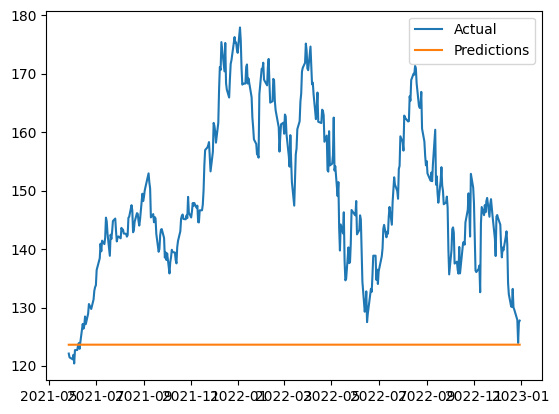

In [28]:
import matplotlib.pyplot as plt 
plt.plot(Test.index,Test,label="Actual")
plt.plot(Test.index, Predictions, label="Predictions")
plt.legend()
plt.show()